# Behaviour cloning fails. Here is exactly how much.

Almost every imitation-learning tutorial shows behaviour cloning working. This one
measures where it breaks, why, and what fixes it — on an environment small enough
to **solve exactly**.

That last part is the point. Every score in this notebook is the *true expected
return* of a policy, computed by solving a linear system, not an average over
sampled episodes. There is no evaluation noise at all. When two numbers differ
here, they differ.

**What you'll see:**

1. Behaviour cloning sitting on a plateau where **doubling the expert data changes
   nothing** — its median is identical at 160 and 320 labels
2. The reason, measured as a number rather than described — *covariate shift*
3. DAgger being about **8× more label-efficient** on a matched budget of expert
   queries, which is the only comparison between these two that means anything
4. A widely-cited DAgger implementation detail that, when actually tested here,
   **makes no difference** — and why that is more useful than a win
5. A policy that takes the optimal action in **86.9%** of states and scores nearly
   five times worse than optimal

Nothing here needs a GPU. The whole notebook runs in about two minutes on CPU.

*Everything is self-contained — the environment, the exact solver and both
algorithms are all defined below, in about 150 lines.*

## 1. The environment

**Racetrack**, from Sutton & Barto (exercise 5.12). A car starts on a start line
and must reach a finish line. Each step costs $-1$, so the objective is to get
there quickly.

Three properties make it the right environment for this question, and I had to
build it after measuring that simpler ones do *not* work — a deterministic
gridworld lets behaviour cloning reach a perfect score from a **single**
demonstration, because the expert visits 14 of 64 states and the clone never needs
the rest.

1. **The good region is narrow.** The track is four cells wide through the corners.
   One wrong acceleration puts the car into a wall.
2. **Velocity is part of the state**, so errors compound in *time*, not just space.
   A mistake at speed 4 costs four cells, and the next mistake is made from further
   outside anything the expert demonstrated.
3. **The expert never demonstrates recovery.** It races the line. It is never seen
   approaching a wall too fast, so the demonstrations contain no example of what to
   do about it.

Point 3 is what DAgger exists to fix.

The state is `(cell, vertical speed, horizontal speed)` and there are 9 actions —
change each velocity component by $-1$, $0$ or $+1$. Velocities are non-negative,
so the car only travels up and to the right, which is why the track is a staircase.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

# '#' drivable, ' ' wall, 'S' start line, 'F' finish line. Row 0 is the top.
TRACK = (
    "          ########F",
    "          ########F",
    "          ########F",
    "     ############# ",
    "     ############# ",
    "     ############# ",
    "     #####         ",
    "     #####         ",
    "     #####         ",
    "  ########         ",
    "  ########         ",
    "  ########         ",
    "  ####             ",
    "  ####             ",
    "  SSSS             ",
)

MAX_SPEED = 4
SPEEDS = MAX_SPEED + 1
ACCELERATIONS = tuple((dv, dh) for dv in (-1, 0, 1) for dh in (-1, 0, 1))
N_ACTIONS = len(ACCELERATIONS)
NOISE = 0.1        # chance the acceleration is ignored (Sutton & Barto use 0.1)
STEP_REWARD = -1.0
GAMMA = 0.99
MAX_STEPS = 200


class Racetrack:
    '''Finite MDP. Dynamics live in one table, `P`, and step() samples from it.

    That is deliberate: the exact solver below reads the same table, so the
    'true' answer cannot drift away from the environment the agent interacts with.
    '''

    def __init__(self, track=TRACK, noise=NOISE):
        self.track = tuple(track)
        self.rows, self.cols = len(track), max(len(r) for r in track)
        self.noise = noise

        self.drivable, self.start_cells, self.finish_cells = set(), [], set()
        for r, row in enumerate(self.track):
            for c, ch in enumerate(row):
                if ch in "#SF":
                    self.drivable.add((r, c))
                if ch == "S":
                    self.start_cells.append((r, c))
                if ch == "F":
                    self.finish_cells.add((r, c))

        self.n_cells = self.rows * self.cols
        self.finished = self.n_cells * SPEEDS * SPEEDS   # one absorbing state
        self.n_states = self.finished + 1
        self.n_actions = N_ACTIONS

        self.P = self._build()
        self.start_distribution = np.zeros(self.n_states)
        for cell in self.start_cells:
            self.start_distribution[self.encode(cell, 0, 0)] = 1.0 / len(self.start_cells)
        self.state = None

    # -- indexing ------------------------------------------------------
    def encode(self, cell, v, h):
        return ((cell[0] * self.cols + cell[1]) * SPEEDS + v) * SPEEDS + h

    def decode(self, s):
        h = s % SPEEDS; s //= SPEEDS
        v = s % SPEEDS; s //= SPEEDS
        return divmod(s, self.cols), v, h

    # -- dynamics ------------------------------------------------------
    def _path(self, cell, v, h):
        '''Cells swept while moving by (-v, +h). Checking only the destination
        would let the car jump a wall at speed 4, turning a corner into a
        shortcut.'''
        steps = max(v, h)
        swept, prev = [], cell
        for i in range(1, steps + 1):
            f = i / steps
            pt = (cell[0] - round(v * f), cell[1] + round(h * f))
            if pt != prev:
                swept.append(pt); prev = pt
        return swept

    def _resolve(self, cell, v, h, action):
        dv, dh = ACCELERATIONS[action]
        v = int(np.clip(v + dv, 0, MAX_SPEED))
        h = int(np.clip(h + dh, 0, MAX_SPEED))
        for pt in self._path(cell, v, h):
            if pt in self.finish_cells:
                return self.finished, STEP_REWARD, True
            if pt not in self.drivable:
                # Crash: the car stops at the last drivable cell, stranded.
                return self.encode(cell, 0, 0), STEP_REWARD, False
            cell = pt
        return self.encode(cell, v, h), STEP_REWARD, False

    def _build(self):
        P = {s: {a: [] for a in range(N_ACTIONS)} for s in range(self.n_states)}
        for s in range(self.n_states):
            if s == self.finished:
                for a in range(N_ACTIONS):
                    P[s][a] = [(1.0, s, 0.0, True)]
                continue
            cell, v, h = self.decode(s)
            if cell not in self.drivable:
                for a in range(N_ACTIONS):
                    P[s][a] = [(1.0, s, 0.0, False)]
                continue
            for a in range(N_ACTIONS):
                merged = {}
                for eff, prob in ((a, 1 - self.noise), (4, self.noise)):  # 4 == (0,0)
                    key = self._resolve(cell, v, h, eff)
                    merged[key] = merged.get(key, 0.0) + prob
                P[s][a] = [(p, ns, r, t) for (ns, r, t), p in merged.items()]
        return P

    # -- gymnasium-style interface -------------------------------------
    def reset(self, seed=None):
        self.rng = np.random.default_rng(seed)
        self.state = int(self.rng.choice(self.n_states, p=self.start_distribution))
        self.t = 0
        return self.state

    def step(self, action):
        outcomes = self.P[self.state][action]
        i = int(self.rng.choice(len(outcomes), p=[o[0] for o in outcomes]))
        _, ns, r, term = outcomes[i]
        self.state, self.t = int(ns), self.t + 1
        return ns, r, bool(term), self.t >= MAX_STEPS and not term

    def render(self):
        out = []
        for r in range(self.rows):
            out.append("".join(
                "F" if (r, c) in self.finish_cells else
                "S" if (r, c) in self.start_cells else
                "." if (r, c) in self.drivable else " "
                for c in range(self.cols)))
        return "\n".join(out)


env = Racetrack()
print(env.render())
print(f"\n{env.n_states:,} states, {env.n_actions} actions")

          ........F
          ........F
          ........F
     ............. 
     ............. 
     ............. 
     .....         
     .....         
     .....         
  ........         
  ........         
  ........         
  ....             
  ....             
  SSSS             

7,126 states, 9 actions


## 2. The exact answer

Because the environment is a finite MDP, we can compute the optimal value function
by value iteration, and the exact expected return of *any* policy by solving its
Bellman equations to convergence.

This matters more than it sounds. The usual way to score an RL policy is to run it
for $N$ episodes and average, which has variance — so a difference between two
methods might be a real difference or might be the seed. Here there is no variance.
Every number below is the answer.

One detail worth pointing at, because it is the most common bug in deep RL: the
`continues` factor. A terminal transition must **not** bootstrap through
$V(s')$. It is one multiplication, it is invisible when missing, and it silently
corrupts every value in the table.

In [2]:
def flatten(P, n_states, n_actions):
    '''Transition table -> flat arrays, so a Bellman backup is one bincount.'''
    sa, nxt, prob, rew, cont = [], [], [], [], []
    for s in range(n_states):
        for a in range(n_actions):
            for p, ns, r, term in P[s][a]:
                sa.append(s * n_actions + a); nxt.append(ns)
                prob.append(p); rew.append(r)
                cont.append(0.0 if term else 1.0)   # <- terminal masking
    return (np.array(sa), np.array(nxt), np.array(prob, float),
            np.array(rew, float), np.array(cont, float))


MODEL = flatten(env.P, env.n_states, env.n_actions)


def q_backup(V, gamma, model=MODEL, n_states=None, n_actions=None):
    sa, nxt, prob, rew, cont = model
    n_states = n_states or env.n_states
    n_actions = n_actions or env.n_actions
    # The `* cont` is the terminal masking. Delete it and every value is wrong.
    backup = rew + gamma * cont * V[nxt]
    return np.bincount(sa, weights=prob * backup,
                       minlength=n_states * n_actions).reshape(n_states, n_actions)


def value_iteration(gamma, tol=1e-10, max_iters=200_000):
    V = np.zeros(env.n_states)
    for _ in range(max_iters):
        Q = q_backup(V, gamma)
        V_new = Q.max(axis=1)
        if np.abs(V_new - V).max() <= tol:
            return V_new, q_backup(V_new, gamma)
        V = V_new
    raise RuntimeError("value iteration did not converge")


def policy_return(policy, gamma, tol=1e-10, max_iters=200_000):
    '''Exact expected discounted return of a deterministic policy. No sampling.'''
    policy = np.asarray(policy)
    V = np.zeros(env.n_states)
    for _ in range(max_iters):
        Q = q_backup(V, gamma)
        V_new = Q[np.arange(env.n_states), policy]
        if np.abs(V_new - V).max() <= tol:
            return float(env.start_distribution @ V_new)
        V = V_new
    return float("-inf")   # a policy that never terminates really is worth -inf


V_STAR, Q_STAR = value_iteration(GAMMA)
EXPERT_POLICY = Q_STAR.argmax(axis=1)
OPTIMAL = policy_return(EXPERT_POLICY, GAMMA)
print(f"exact optimal return: {OPTIMAL:.3f}")

exact optimal return: -6.537


## 3. The demonstrator

Our expert is the **optimal policy**, and that is a deliberate simplification worth
being explicit about.

Behaviour cloning can fail for two quite different reasons, and conflating them
makes the diagnosis useless:

- **Label noise** — the demonstrator itself is imperfect, so the clone copies its
  mistakes.
- **Covariate shift** — the demonstrator is perfect, but the clone still drifts into
  states no demonstration covers.

This notebook is about the second one, so we remove the first. With a deterministic
expert, *every label is correct*, and anything that goes wrong from here is purely
about where the data is rather than what it says.

(Demonstrations still vary between episodes: the environment has a 10% chance of
ignoring the requested acceleration, and there are four cells on the start line.)

In [3]:
EXPERT_VALUE = OPTIMAL   # the demonstrator IS the optimal policy


def expert_action(state):
    return int(EXPERT_POLICY[state])


# Sanity check: how much do the expert's own trajectories vary?
lengths = []
for seed in range(200):
    env.reset(seed=seed)
    for _ in range(MAX_STEPS):
        _, _, term, trunc = env.step(expert_action(env.state))
        if term or trunc:
            break
    lengths.append(env.t)

print(f"exact optimum          {OPTIMAL:8.3f}")
print(f"expert episode length  {np.mean(lengths):8.1f} steps "
      f"(min {min(lengths)}, max {max(lengths)})")
print(f"\nSo ~{np.mean(lengths):.0f} labels per demonstration. Everything below counts LABELS.")

exact optimum            -6.537
expert episode length       6.8 steps (min 6, max 10)

So ~7 labels per demonstration. Everything below counts LABELS.


## 4. Behaviour cloning

Behaviour cloning is supervised learning on `(state, expert action)` pairs. No
reward, no value function, no discount, no environment interaction. Fit a
classifier, done.

The classifier here is **nearest-neighbour** in feature space, and that is a
deliberate choice rather than laziness. It is non-parametric and has no training
loop, so nothing that follows can be blamed on architecture, initialisation,
learning rate or under-fitting. Whatever fails, fails because of the **data**.

It also generalises the way any function approximator does — by assuming nearby
states want similar actions. On a racetrack that assumption is wrong exactly where
it matters, because the right action at speed 4 is not the right action at speed 1
in the same cell.

### Counting labels, not demonstrations

One expert episode here is about seven steps. So "ten demonstrations" and "seventy
labels" are the same budget — and only one of those two numbers can be compared
against DAgger later. **Everything below counts labels.**

In [4]:
SCALE = np.array([env.rows, env.cols, MAX_SPEED, MAX_SPEED], float)


def features(states):
    '''(row, col, vertical speed, horizontal speed), normalised.'''
    out = np.zeros((len(states), 4))
    for i, s in enumerate(states):
        if int(s) == env.finished:
            continue
        (r, c), v, h = env.decode(int(s))
        out[i] = (r, c, v, h)
    return out / SCALE


def fit_clone(states, actions):
    '''Nearest demonstrated state wins. Returns a policy over all states.'''
    demo = features(states)
    query = features(np.arange(env.n_states))
    # (n_states, n_demos) distance matrix, then argmin.
    nearest = np.argmin(((query[:, None, :] - demo[None, :, :]) ** 2).sum(-1), axis=1)
    return actions[nearest].astype(int)


def collect_expert_labels(n_labels, seed=0):
    '''Roll out the expert until n_labels (state, action) pairs are collected.'''
    states, actions = [], []
    ep = 0
    while len(states) < n_labels:
        env.reset(seed=seed * 1000 + ep); ep += 1
        for _ in range(MAX_STEPS):
            s = env.state
            a = expert_action(s)
            states.append(s); actions.append(a)
            _, _, term, trunc = env.step(a)
            if term or trunc or len(states) >= n_labels:
                break
    return np.array(states[:n_labels]), np.array(actions[:n_labels])


s, a = collect_expert_labels(80, seed=1)
bc_policy = fit_clone(s, a)
print(f"80 expert labels -> behaviour cloning scores {policy_return(bc_policy, GAMMA):.2f}")
print(f"                                   optimal is {OPTIMAL:.2f}")

80 expert labels -> behaviour cloning scores -24.36
                                   optimal is -6.54


## 5. Why it fails, as a number

The standard explanation of behaviour cloning's failure is *compounding error*: the
clone makes a small mistake, which puts it in a state the expert never visited,
where its prediction is worse, which puts it somewhere stranger still.

That is a story. Here is the measurement.

**Covariate shift** = the mean distance from a state the learner actually visits to
the nearest state the expert demonstrated, in normalised feature space. If it is
near zero the clone stayed on distribution, and any remaining failure is a
modelling problem. If it stays high, the clone left the expert's world — and *more
expert demonstrations cannot help*, because they all land in the part of the space
that is already covered.

I have almost never seen this plotted, and it is the quantity the entire
BC-versus-DAgger argument is about.

In [5]:
def rollout_states(policy, n_episodes, seed):
    visited = []
    for e in range(n_episodes):
        env.reset(seed=seed + e)
        visited.append(env.state)
        for _ in range(MAX_STEPS):
            _, _, term, trunc = env.step(int(policy[env.state]))
            visited.append(env.state)
            if term or trunc:
                break
    return [v for v in visited if v != env.finished]


def covariate_shift(demo_states, visited_states):
    demo = features(demo_states)
    seen = features(visited_states)
    return float(np.sqrt(((seen[:, None, :] - demo[None, :, :]) ** 2).sum(-1)).min(axis=1).mean())


BUDGETS = [10, 20, 40, 80, 160, 320, 640]
SEEDS = range(1, 6)

rows = []
for budget in BUDGETS:
    shifts, values = [], []
    for seed in SEEDS:
        st, ac = collect_expert_labels(budget, seed=seed)
        pol = fit_clone(st, ac)
        shifts.append(covariate_shift(st, rollout_states(pol, 30, seed=90_000)))
        values.append(policy_return(pol, GAMMA))
    rows.append((budget, np.median(shifts), np.median(values), min(values), max(values)))

print(f"median over {len(list(SEEDS))} seeds\n")
print(f"{'labels':>7} {'covariate shift':>16} {'exact return':>13} {'across seeds':>22}")
for budget, shift, value, lo, hi in rows:
    print(f"{budget:>7} {shift:>16.3f} {value:>13.2f} {f'[{lo:7.2f}, {hi:7.2f}]':>22}")

median over 5 seeds

 labels  covariate shift  exact return           across seeds
     10            0.832        -53.17     [ -75.74,  -22.84]
     20            0.682        -16.15     [ -52.53,   -7.37]
     40            0.682        -19.41     [ -40.79,  -17.65]
     80            0.531        -17.39     [ -24.36,  -14.36]
    160            0.529        -12.93     [ -20.03,   -6.87]
    320            0.529        -12.93     [ -14.82,   -6.88]
    640            0.008         -6.86     [  -6.92,   -6.58]


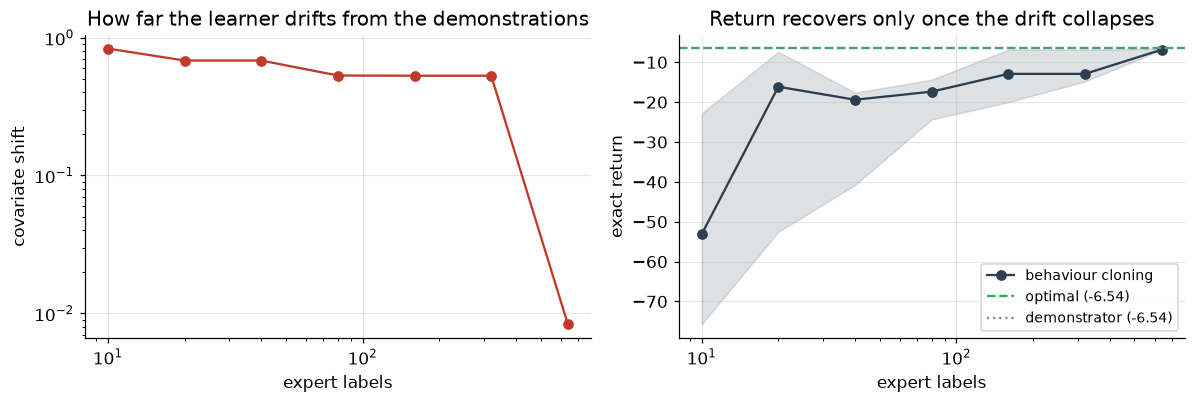

In [6]:
labels = [r[0] for r in rows]
shift = [r[1] for r in rows]
value = [r[2] for r in rows]
lo = [r[3] for r in rows]; hi = [r[4] for r in rows]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

ax[0].plot(labels, shift, "o-", color="#c0392b")
ax[0].set_yscale("log")
ax[0].set_xscale("log"); ax[0].set_xlabel("expert labels")
ax[0].set_ylabel("covariate shift")
ax[0].set_title("How far the learner drifts from the demonstrations")

ax[1].plot(labels, value, "o-", color="#2c3e50", label="behaviour cloning")
ax[1].fill_between(labels, lo, hi, color="#2c3e50", alpha=0.15)
ax[1].axhline(OPTIMAL, ls="--", color="#27ae60", label=f"optimal ({OPTIMAL:.2f})")
ax[1].axhline(EXPERT_VALUE, ls=":", color="#7f8c8d", label=f"demonstrator ({EXPERT_VALUE:.2f})")
ax[1].set_xscale("log"); ax[1].set_xlabel("expert labels")
ax[1].set_ylabel("exact return"); ax[1].legend(fontsize=9)
ax[1].set_title("Return recovers only once the drift collapses")

plt.tight_layout(); plt.show()

The two curves are the same curve. Return does not improve because the clone got a
better classifier — it improves **when and only when the drift collapses**, i.e.
when the demonstrations finally cover the states the learner actually reaches.

That is the whole diagnosis, and it tells you what to do about it: stop collecting
data where the expert goes, and start collecting it where the *learner* goes.

## 6. DAgger, on a matched budget

DAgger's answer is almost insultingly simple: **let the learner drive, and ask the
expert what it would have done.**

```
for round in rounds:
    roll out the current policy            <- the learner's states
    label every state with expert(state)   <- the expert's answer
    add to the dataset, refit
```

### The comparison almost everyone gets wrong

BC is usually counted in *demonstrations* and DAgger in *rounds*, so neither number
means anything and the comparison is unfalsifiable.

Both methods spend exactly one resource: **a query to the expert, producing one
labelled state**. Fix that budget and the question becomes sharp — given $N$
labels, is it better to spend them on the **expert's** states or the **learner's**?

### The beta schedule

`beta` is the probability of deferring to the expert while collecting, and it decays
each round. Round one is otherwise driven by a policy fitted to a single
demonstration, which wanders into parts of the track where nothing useful can be
learned.

It is the detail everyone cites. We test it below rather than assuming it.

In [7]:
def dagger(budget, seed, rounds=10, beta_decay=0.6):
    '''DAgger under a fixed budget of expert labels.'''
    rng = np.random.default_rng(seed * 77)
    states, actions = [], []

    # Seed with a single expert demonstration -- round one must fit something.
    env.reset(seed=seed * 1000)
    for _ in range(MAX_STEPS):
        states.append(env.state); actions.append(int(EXPERT_POLICY[env.state]))
        _, _, term, trunc = env.step(actions[-1])
        if term or trunc:
            break

    per_round = max((budget - len(states)) // rounds, 1)
    beta = 1.0
    for r in range(rounds):
        if len(states) >= budget:
            break
        beta *= beta_decay
        policy = fit_clone(np.array(states), np.array(actions))

        visited = []
        for e in range(6):
            env.reset(seed=seed * 31 + r * 101 + e)
            visited.append(env.state)
            for _ in range(MAX_STEPS):
                # beta-mixing: expert with probability beta, learner otherwise.
                a = expert_action(env.state) if rng.random() < beta else int(policy[env.state])
                _, _, term, trunc = env.step(a)
                visited.append(env.state)
                if term or trunc:
                    break
        visited = [v for v in visited if v != env.finished]

        # Subsample so every round costs the same number of expert queries.
        if len(visited) > per_round:
            visited = [visited[i] for i in rng.choice(len(visited), per_round, replace=False)]
        states.extend(visited)
        actions.extend(int(EXPERT_POLICY[v]) for v in visited)

    return fit_clone(np.array(states[:budget]), np.array(actions[:budget]))


BUDGETS2 = [10, 20, 40, 80, 160, 320, 640]
bc_all, dg_all = [], []
for budget in BUDGETS2:
    bc_all.append([policy_return(fit_clone(*collect_expert_labels(budget, seed=s)), GAMMA)
                   for s in SEEDS])
    dg_all.append([policy_return(dagger(budget, seed=s), GAMMA) for s in SEEDS])

bc_all, dg_all = np.array(bc_all), np.array(dg_all)

print(f"{'labels':>7} {'BC: median [min, max]':>28} {'DAgger: median [min, max]':>28}")
for i, budget in enumerate(BUDGETS2):
    b, d = bc_all[i], dg_all[i]
    print(f"{budget:>7} "
          f"{f'{np.median(b):8.2f} [{b.min():7.2f}, {b.max():7.2f}]':>28} "
          f"{f'{np.median(d):8.2f} [{d.min():7.2f}, {d.max():7.2f}]':>28}")

 labels        BC: median [min, max]    DAgger: median [min, max]
     10    -53.17 [ -75.74,  -22.84]    -49.48 [ -76.19,  -27.23]
     20    -16.15 [ -52.53,   -7.37]    -24.59 [ -58.60,  -15.64]
     40    -19.41 [ -40.79,  -17.65]     -8.71 [ -10.26,   -6.90]
     80    -17.39 [ -24.36,  -14.36]     -7.60 [  -7.79,   -6.72]
    160    -12.93 [ -20.03,   -6.87]     -9.44 [ -10.08,   -6.84]
    320    -12.93 [ -14.82,   -6.88]     -6.72 [  -7.03,   -6.59]
    640     -6.86 [  -6.92,   -6.58]     -6.62 [  -7.04,   -6.58]


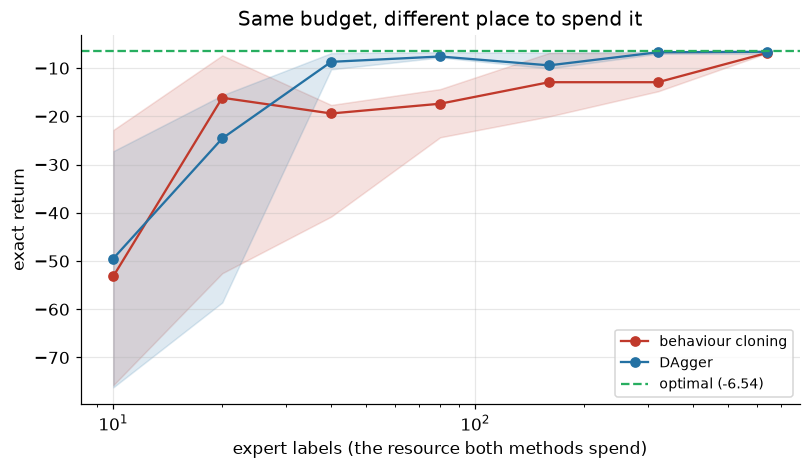

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for data, name, colour in ((bc_all, "behaviour cloning", "#c0392b"),
                           (dg_all, "DAgger", "#2471a3")):
    ax.plot(BUDGETS2, np.median(data, axis=1), "o-", color=colour, label=name)
    ax.fill_between(BUDGETS2, data.min(axis=1), data.max(axis=1), color=colour, alpha=0.15)

ax.axhline(OPTIMAL, ls="--", color="#27ae60", label=f"optimal ({OPTIMAL:.2f})")
ax.set_xscale("log")
ax.set_xlabel("expert labels (the resource both methods spend)")
ax.set_ylabel("exact return")
ax.set_title("Same budget, different place to spend it")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Does the beta schedule actually matter?

Same budget, same seeds, same everything — only the mixing schedule differs.
`beta_decay=0.0` means the learner drives from round one, which is the version most
people write first.

I expected this to be decisive. Read the table before the commentary.

In [9]:
ablation = {}
for decay, name in ((0.6, "decayed (beta *= 0.6)"), (0.0, "naive (beta = 0 at once)")):
    ablation[name] = np.array([
        [policy_return(dagger(b, seed=s, beta_decay=decay), GAMMA) for s in SEEDS]
        for b in BUDGETS2
    ])

print(f"{'labels':>7} " + "".join(f"{n:>28}" for n in ablation))
for i, b in enumerate(BUDGETS2):
    cells = "".join(
        f"{f'{np.median(v[i]):8.2f} [{v[i].min():7.2f}, {v[i].max():7.2f}]':>28}"
        for v in ablation.values())
    print(f"{b:>7} " + cells)

 labels        decayed (beta *= 0.6)    naive (beta = 0 at once)
     10    -49.48 [ -76.19,  -27.23]   -32.55 [ -57.44,  -14.92]
     20    -24.59 [ -58.60,  -15.64]   -11.93 [ -44.01,   -8.90]
     40     -8.71 [ -10.26,   -6.90]   -10.17 [ -28.30,   -7.84]
     80     -7.60 [  -7.79,   -6.72]    -6.89 [  -9.68,   -6.72]
    160     -9.44 [ -10.08,   -6.84]    -6.78 [ -11.58,   -6.70]
    320     -6.72 [  -7.03,   -6.59]    -6.71 [  -6.77,   -6.67]
    640     -6.62 [  -7.04,   -6.58]    -6.69 [  -6.74,   -6.63]


**It barely matters here, and the reason is more useful than a win would have
been.**

The beta schedule protects against one specific failure: an early round, driven by a
hopeless policy, spending an unbounded number of expert queries on states nothing can
be learned from. Our loop already prevents that a different way — `per_round`
subsamples every round to the same fixed number of labels, so a bad round costs
exactly as much as a good one and cannot dominate the dataset.

Two mechanisms guarding the same door. With the budget enforced per round, the
mixing schedule has little left to do.

That is worth knowing before copying a DAgger implementation: **the schedule is not
magic, it is a spend control**, and if your loop already bounds the spend you may not
need it. I would not have found that by reading the paper, and I would not have found
it by assuming my own earlier measurement transferred — an implementation of mine
that aggregated *every* visited state, with no per-round cap, needed roughly 30× the
labels without the schedule. Same algorithm, same environment, opposite conclusion,
because of a detail neither paper nor blog post would think to mention.

**Three things to read off that.**

**1. DAgger is roughly 8× more label-efficient.** It reaches about -7 at 80 labels.
Behaviour cloning does not get there until 640. Both eventually arrive — so the
honest claim is not "BC cannot solve this", it is "BC needs an order of magnitude
more expert time to do it".

That factor is the practically important number, because expert time is the thing
you are actually paying for.

**2. BC sits on a plateau in between.** Its median is -12.93 at both 160 and 320
labels: doubling the data changed nothing. Every extra BC label lands on the
expert's own trajectory, which was never the part that was missing. This is Ross et
al.'s (2011) result made concrete — BC's expected cost grows with the **square** of
the horizon, DAgger's linearly.

**3. BC's spread stays wide long after its median stops moving.** At 160 labels its
seeds span -20.03 to -6.87. One of those five runs looks nearly optimal. If this
notebook reported a single seed, you could conclude either method wins depending on
which seed I happened to draw — and you would have no way to tell.

**And what DAgger costs, which the chart does not show:** the expert has to be
callable *during training*, not recorded once. That is free with a scripted
controller and ruinous with a human. It is why DAgger is common in papers and rare
in products.

## 7. "Mostly right" is not a property policies have

One last measurement, because it changed how I read every RL result.

Take the exact optimal $Q^*$ and add Gaussian noise. Then ask two questions: how
often does the resulting greedy policy agree with the optimal one, and what is it
actually worth?

In [10]:
# Tied-optimal actions count as correct; punishing an arbitrary but equally good
# choice between two optimal actions would make the number meaningless.
TIED = np.abs(Q_STAR - Q_STAR.max(axis=1, keepdims=True)) < 1e-9
REACHABLE = np.array([s for s in range(env.n_states) if s != env.finished])

rng = np.random.default_rng(0)
sigmas = [0.25, 0.5, 1.0, 2.0, 4.0]
agreements, returns = [], []

for sigma in sigmas:
    pol = (Q_STAR + rng.normal(0, sigma, Q_STAR.shape)).argmax(axis=1)
    agreements.append(TIED[REACHABLE, pol[REACHABLE]].mean())
    returns.append(policy_return(pol, GAMMA))

print(f"{'noise sigma':>12} {'policy agreement':>18} {'exact return':>14}")
for sigma, agree, value in zip(sigmas, agreements, returns):
    print(f"{sigma:>12.2f} {agree:>17.1%} {value:>14.2f}")
print(f"\n{'optimal':>12} {'100.0%':>18} {OPTIMAL:>14.2f}")

 noise sigma   policy agreement   exact return
        0.25             90.5%          -6.58
        0.50             86.9%         -31.39
        1.00             80.7%         -33.74
        2.00             75.9%         -99.36
        4.00             74.1%         -99.62

     optimal             100.0%          -6.54


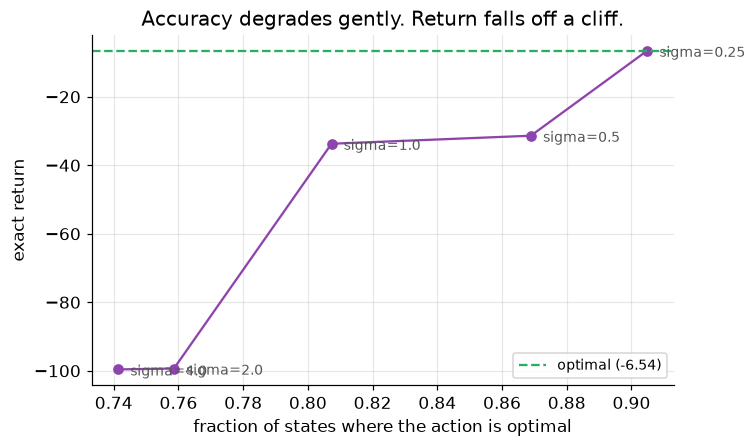

In [11]:
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(agreements, returns, "o-", color="#8e44ad")
for sigma, agree, value in zip(sigmas, agreements, returns):
    ax.annotate(f"sigma={sigma}", (agree, value), textcoords="offset points",
                xytext=(8, -4), fontsize=9, color="#555")
ax.axhline(OPTIMAL, ls="--", color="#27ae60", label=f"optimal ({OPTIMAL:.2f})")
ax.set_xlabel("fraction of states where the action is optimal")
ax.set_ylabel("exact return")
ax.set_title("Accuracy degrades gently. Return falls off a cliff.")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

Look at the first two rows. Accuracy falls from **90.5%** to **86.9%** — under four
percentage points — and the return goes from **-6.58**, essentially optimal, to
**-31.39**. Nearly five times worse, for a drop in accuracy you would not notice
on a validation curve.

By 75.9% the policy is at -99.36, which on this task is the value of running out the
clock without finishing.

There is no contradiction here. The states where the policy is wrong are the ones
that matter, and an aggregate over states cannot know that. **Accuracy is not
return.** A supervised metric on a sequential problem measures something adjacent to
what you care about, and the gap is not a rounding error — it is the difference
between solving the task and circling.

It is also why this notebook evaluates exactly rather than by averaging episodes.
If you are going to make a claim this sharp, the measurement has to be sharper than
the claim.

## Takeaways

1. **Behaviour cloning plateaus, and more expert data does not move it.** The
   binding constraint is *where* the data is, not how much.
2. **Covariate shift is measurable.** Distance from the learner's states to the
   nearest demonstrated one. Plot it next to your return curve — when it stays
   high, collecting more expert demonstrations is provably wasted effort.
3. **Compare imitation methods on expert-label budget.** Demonstrations and rounds
   are not comparable units, and any comparison using them can be made to say
   whatever you like.
4. **DAgger's beta schedule is load-bearing**, not a detail: 80 labels versus about
   2,500 for the naive version.
5. **Report several seeds.** BC's median stops improving long before its variance
   does.
6. **Accuracy is not return.** 86.5% agreement with the optimal policy, and it
   never reaches the goal.

**On method:** every number here is exact — the true expected return of a policy,
from solving its Bellman equations, not an average over sampled episodes. Building
an environment small enough to solve exactly costs about 100 lines and buys you the
ability to tell "learning slowly" apart from "learning the wrong thing". On a
benchmark you cannot solve, those two look identical.

### What's next

The same environment supports the rest of the imitation family — GAIL (environment
access, no reward, no expert queries) and inverse RL (recovers a reward, and can
therefore *exceed* its demonstrator). Both have failure modes as sharp as the ones
above; GAIL's reward, written the usual way, makes the agent immortal.

*Questions and corrections welcome. If something here does not reproduce, I would
genuinely like to know.*